In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, glob, os, random
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


### parameters

In [2]:
version = ['patients', 'hard', 'no_noise'][0]

### generate trials

In [3]:
np.random.seed(42)
trial_info, trial_key, blockN = [], 0, 0

for run in [1,2]:

    for div in [0, -.2, .2]:
        
        blockN += 1

        # 1. first, sample 20 positions per condition
        if div == 0:
            stim_vect = np.arange(.1, 4.0, .2)          
        elif div == -.2:
            stim_vect = np.concatenate([ np.arange(.1, 1.0, .2), np.arange(.1, 1.0, .2), np.arange(1.1, 3.0, .2) ])
        elif div == .2:
            stim_vect = np.concatenate([ np.arange(1.1, 3.0, .2), np.arange(3.1, 4.0, .2), np.arange(3.1, 4.0, .2) ])

        stim_file_pos_ls = np.tile(stim_vect, 2) # for 2x stim samples per block
        stim_file_pos_ls = np.round(np.sort(stim_file_pos_ls), 1)

        # 2. sample valence display order
        shape_order_ls = ['curv_flat', 'flat_curv'] * 20

        # 3. sample noise
        noiseA, noiseB = (1.0, 3.0) if version == 'patients' else (0.0, 4.0) if version == 'hard' else (2.0, 2.0)
        noise_pos_ls = np.random.permutation([noiseA] * 20 + [noiseB] * 20)

        # 4. sample marker_init: 50-50 on right-left for each target category
        marker_init_dir = np.random.permutation([1, 1, -1, -1] * 40)

        for i in range(len(stim_file_pos_ls)):
            
            # set some vars outside the loop
            stim_pos = round((stim_file_pos_ls[i] - 2) * .2, 2) # convert file_pos to actual pos
            target_pos = stim_pos if shape_order_ls[i] == 'curv_flat' else -stim_pos
            shape = 'curv' if stim_pos <= div else 'flat'
            marker_init = target_pos # start at target, then move left or right based on marker_init_dir
            marker2target = abs(target_pos - marker_init)

            while abs(target_pos - marker_init) < .05 or abs(target_pos - marker_init) >= .6 \
                  or marker_init==div: #  too close/far w.r.t target, or on divider
                if marker_init_dir[i] < 0:
                    marker_init = np.round( np.random.choice(np.arange(-.4, div, .004)), 3) # random.uniform(-.4, div)
                elif marker_init_dir[i] > 0:
                    marker_init = np.round( np.random.choice(np.arange(div, .4, .004)), 3) # random.uniform(div, .4)

            img_prefix = 'input_data/stims/Shape_'

            # reminder: stim_file_pos (0,4), stim_pos (-.4,.4), target (-.4,.4)
            trial_info.append({
                    'blockN': blockN,
                    'run': run,
                    'condition': 'baseline' if div == 0 else 'curv_comp' if div == -.2 else 'flat_comp',
                    # consider condition as shape_cond (as opposed to val_cond)
                    
                    'trial_key': trial_key,

                    'stim_file_pos': stim_file_pos_ls[i],
                    'stim_pos': stim_pos,
                    # consider stim_pos as true_stim
                    
                    'noise_pos': noise_pos_ls[i],
                    'marker_init': marker_init,
                    'shape': shape,

                    'shape_order': shape_order_ls[i],
                    'true_div': div,
                    'div_pos': div if shape_order_ls[i] == 'curv_flat' else -div,
                    # consider div_pos as target_div; its where the div appears, which is counterbalanced
                    
                    'target_pos': stim_pos if shape_order_ls[i] == 'curv_flat' else -stim_pos,

                    # 'valence': 'pen' if (blockN <= 3) == (shape == 'curv') else 'rew',
                    'valence': 'pen' if ((blockN <= 3 and shape == 'curv') or (blockN > 3 and shape == 'flat')) else 'rew',
                    # consider pen as loss, rew as gain

                    'target_file': f'{img_prefix}{stim_file_pos_ls[i]}0_{noise_pos_ls[i]}0.png',
                    # left img
                    'img1_file':   f'{img_prefix}0.00_2.00.png' if shape_order_ls[i] == 'curv_flat'\
                            else   f'{img_prefix}4.00_2.00.png',
                    # right img
                    'img2_file':   f'{img_prefix}4.00_2.00.png' if shape_order_ls[i] == 'curv_flat'\
                            else   f'{img_prefix}0.00_2.00.png'
                    })
            
            trial_key += 1

            
df = pd.DataFrame(trial_info)
print(f'version: {version}')

version: patients


In [4]:
df['valence'].value_counts()

valence
pen    120
rew    120
Name: count, dtype: int64

### plotting variables

In [5]:
norm_ticks, norm_ticklabels = np.linspace(-.4, .4, 5), np.linspace(0, 1, 5)
w = 0.015

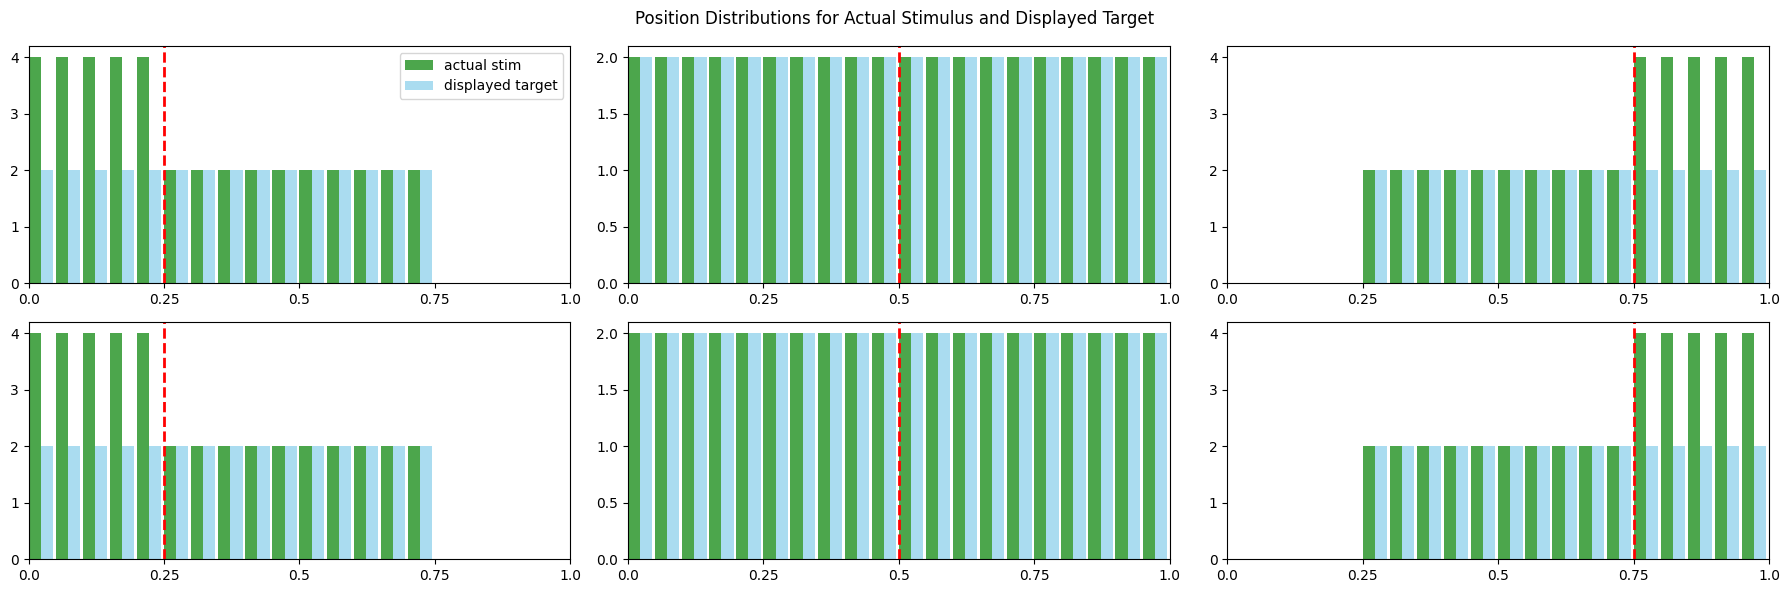

In [6]:
n_runs, n_conds = 2, 3
fig, axs = plt.subplots(n_runs, n_conds, figsize=(n_conds*6, n_runs*3))
axs, ax = axs.flatten(), 0

step = 0.04  # fixed step between stim positions

plt.suptitle('Position Distributions for Actual Stimulus and Displayed Target')

for run in [1,2]:
    for cond in ['curv_comp', 'baseline', 'flat_comp']:

        df_block = df[(df['run'] == run) & (df['condition'] == cond)]

        # calculate bin edges which depends on codnition
        pos_min, pos_max = df_block['stim_pos'].min(), df_block['stim_pos'].max()
        bin_edges = np.arange(pos_min - step/2, pos_max + step, step)

        # complicated hist code
        w = step * 0.45
        axs[ax].bar(bin_edges[:-1],     df_block['stim_pos'].value_counts(bins=bin_edges, sort=False).values,   width=w,  align='edge', color='green',   alpha=0.7, label='actual stim')
        axs[ax].bar(bin_edges[:-1] + w, df_block['target_pos'].value_counts(bins=bin_edges, sort=False).values, width=w,  align='edge', color='skyblue', alpha=0.7, label='displayed target')

        axs[ax].axvline(x=df_block['true_div'].iloc[0], color='red', linestyle='--', linewidth=2)
        axs[ax].set(xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels)
        axs[0].legend()
        
        ax += 1

plt.tight_layout()
plt.show()


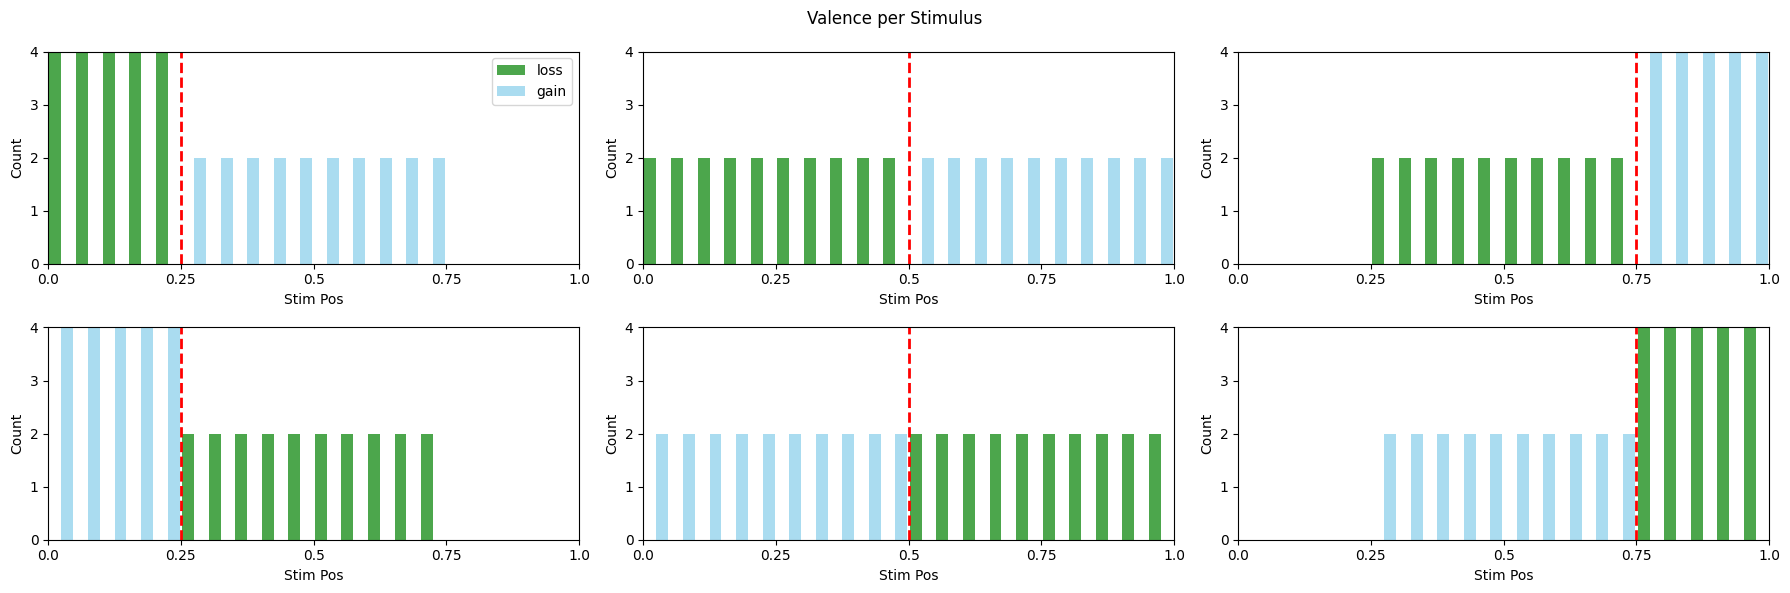

In [7]:
df['valence_direction'] = df['valence'].map({'rew': 1, 'pen': -1})

fig, axs = plt.subplots(n_runs, n_conds, figsize=(n_conds*6, n_runs*3))
axs, ax = axs.flatten(), 0

plt.suptitle('Valence per Stimulus')

for run in [1, 2]:
    for cond in ['curv_comp', 'baseline', 'flat_comp']:
        df_block = df[(df['run'] == run) & (df['condition'] == cond)]
        stim_positions = sorted(df_block['stim_pos'].unique())

        counts_neg = [len(df_block[(df_block['stim_pos'] == s) & (df_block['valence_direction'] == -1)]) for s in stim_positions]
        counts_pos = [len(df_block[(df_block['stim_pos'] == s) & (df_block['valence_direction'] ==  1)]) for s in stim_positions]

        s = np.array(stim_positions)
        axs[ax].bar(s - w/2, counts_neg, width=w, color='green',   alpha=0.7, label='loss')
        axs[ax].bar(s + w/2, counts_pos, width=w, color='skyblue', alpha=0.7, label='gain')
        axs[ax].axvline(x=df_block['true_div'].iloc[0], color='red', linestyle='--', linewidth=2)
        axs[ax].set(xlabel='Stim Pos', ylabel='Count',
                    xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels, ylim=(0, 4))
        axs[0].legend()
        ax += 1

plt.tight_layout()
plt.show()


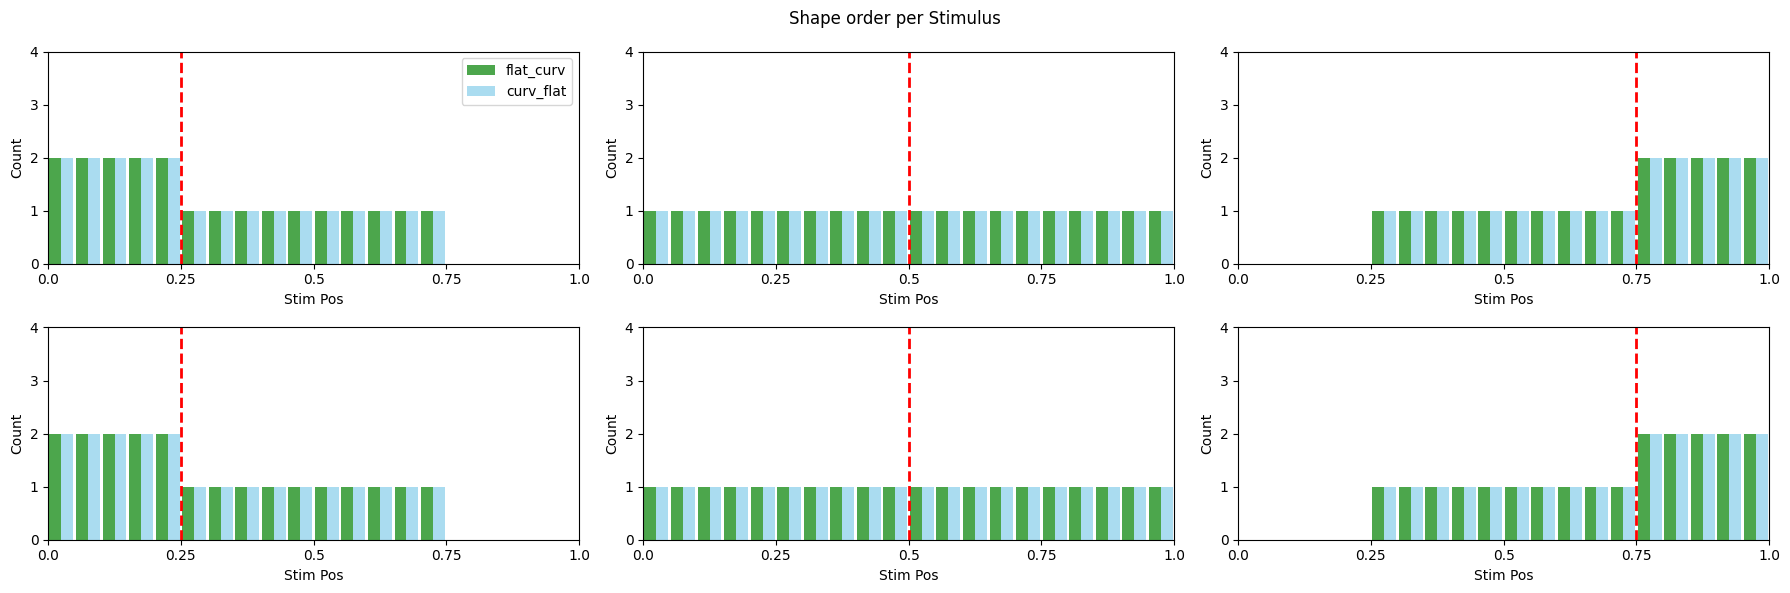

In [8]:
df['direction'] = df['shape_order'].map({'curv_flat': 1, 'flat_curv': -1})

fig, axs = plt.subplots(n_runs, n_conds, figsize=(n_conds*6, n_runs*3))
axs, ax = axs.flatten(), 0

plt.suptitle('Shape order per Stimulus')

for run in [1, 2]:
    for cond in ['curv_comp', 'baseline', 'flat_comp']:
        df_block = df[(df['run'] == run) & (df['condition'] == cond)]
        stim_positions = sorted(df_block['stim_pos'].unique())

        counts_neg = [len(df_block[(df_block['stim_pos'] == s) & (df_block['direction'] == -1)]) for s in stim_positions]
        counts_pos = [len(df_block[(df_block['stim_pos'] == s) & (df_block['direction'] ==  1)]) for s in stim_positions]

        s = np.array(stim_positions)
        axs[ax].bar(s - w/2, counts_neg, width=w, color='green',   alpha=0.7, label='flat_curv')
        axs[ax].bar(s + w/2, counts_pos, width=w, color='skyblue', alpha=0.7, label='curv_flat')
        axs[ax].axvline(x=df_block['true_div'].iloc[0], color='red', linestyle='--', linewidth=2)
        axs[ax].set(xlabel='Stim Pos', ylabel='Count',
                    xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels, ylim=(0, 4))
        axs[0].legend()
        ax += 1

plt.tight_layout()
plt.show()


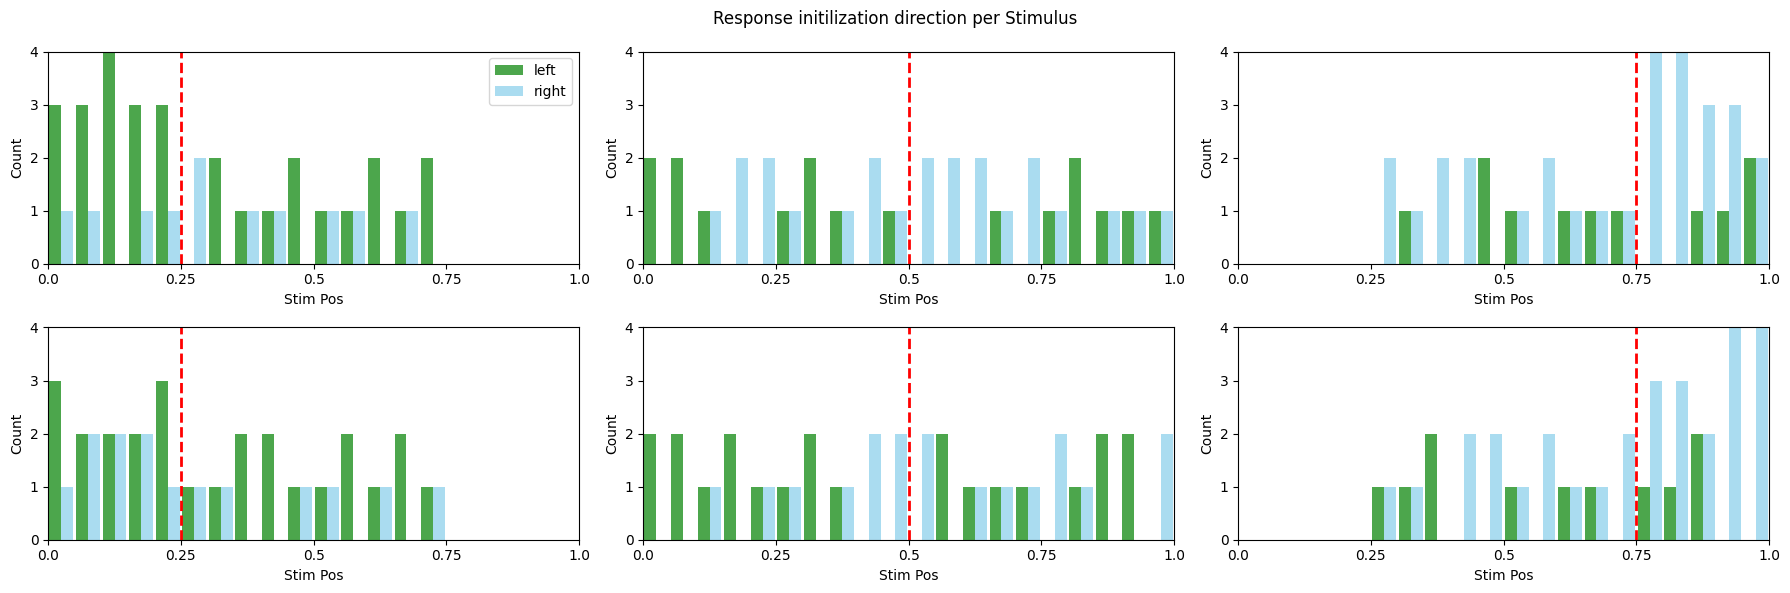

In [9]:
df['marker_direction'] = np.sign(df['marker_init'] - df['div_pos'])

fig, axs = plt.subplots(n_runs, n_conds, figsize=(n_conds*6, n_runs*3))
axs, ax = axs.flatten(), 0

plt.suptitle('Response initilization direction per Stimulus')

for run in [1, 2]:
    for cond in ['curv_comp', 'baseline', 'flat_comp']:
        df_block = df[(df['run'] == run) & (df['condition'] == cond)]
        stim_positions = sorted(df_block['stim_pos'].unique())

        counts_neg = [len(df_block[(df_block['stim_pos'] == s) & (df_block['marker_direction'] == -1)]) for s in stim_positions]
        counts_pos = [len(df_block[(df_block['stim_pos'] == s) & (df_block['marker_direction'] ==  1)]) for s in stim_positions]

        s = np.array(stim_positions)
        axs[ax].bar(s - w/2, counts_neg, width=w, color='green',   alpha=0.7, label='left')
        axs[ax].bar(s + w/2, counts_pos, width=w, color='skyblue', alpha=0.7, label='right')
        axs[ax].axvline(x=df_block['true_div'].iloc[0], color='red', linestyle='--', linewidth=2)
        axs[ax].set(xlabel='Stim Pos', ylabel='Count',
                    xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels, ylim=(0, 4))
        axs[0].legend()
        ax += 1

plt.tight_layout()
plt.show()


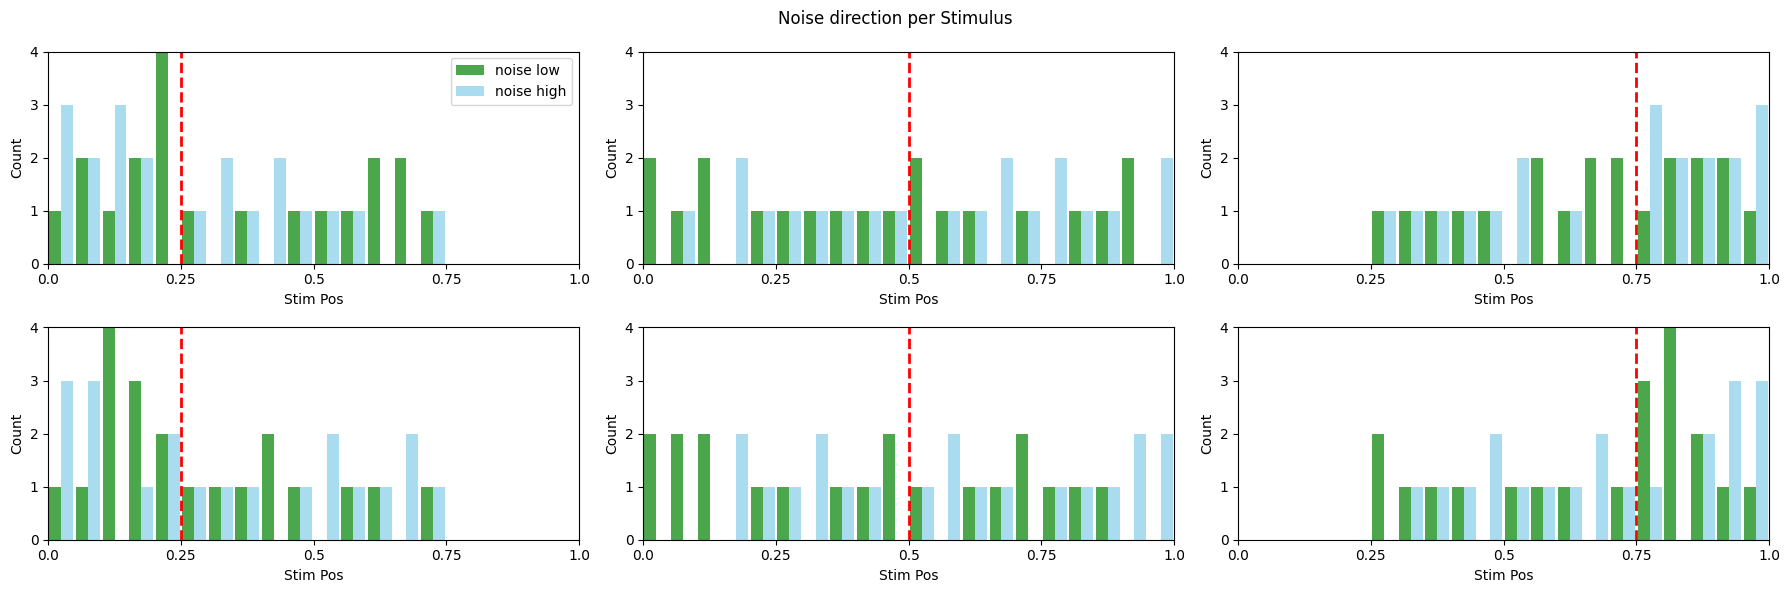

In [10]:
df['noise_direction'] = np.sign(df['noise_pos'] - 2.0)

# --- noise_direction per stim pos ---
n_runs, n_conds = 2, 3
fig, axs = plt.subplots(n_runs, n_conds, figsize=(n_conds*6, n_runs*3))
axs, ax = axs.flatten(), 0

plt.suptitle('Noise direction per Stimulus')

for run in [1, 2]:
    for cond in ['curv_comp', 'baseline', 'flat_comp']:
        
        df_block = df[(df['run'] == run) & (df['condition'] == cond)]
        stim_positions = sorted(df_block['stim_pos'].unique())

        counts_neg = [len(df_block[(df_block['stim_pos'] == s) & (df_block['noise_direction'] == -1)]) for s in stim_positions]
        counts_pos = [len(df_block[(df_block['stim_pos'] == s) & (df_block['noise_direction'] ==  1)]) for s in stim_positions]

        s = np.array(stim_positions)
        axs[ax].bar(s - w/2, counts_neg, width=w, color='green',   alpha=0.7, label='noise low')
        axs[ax].bar(s + w/2, counts_pos, width=w, color='skyblue', alpha=0.7, label='noise high')
        axs[ax].axvline(x=df_block['true_div'].iloc[0], color='red', linestyle='--', linewidth=2)
        axs[ax].set(xlabel='Stim Pos', ylabel='Count',
                    xlim=(-.4, .4), xticks=norm_ticks, xticklabels=norm_ticklabels, ylim=(0, 4))
        
        axs[0].legend()
        ax += 1

plt.tight_layout()
plt.show()


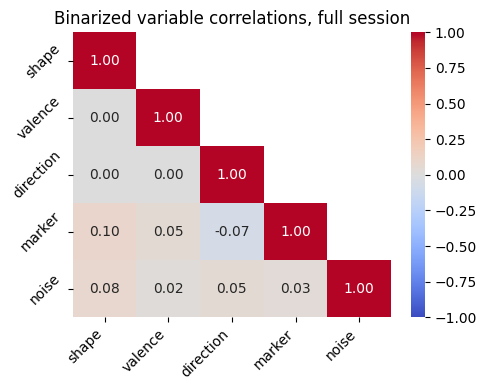

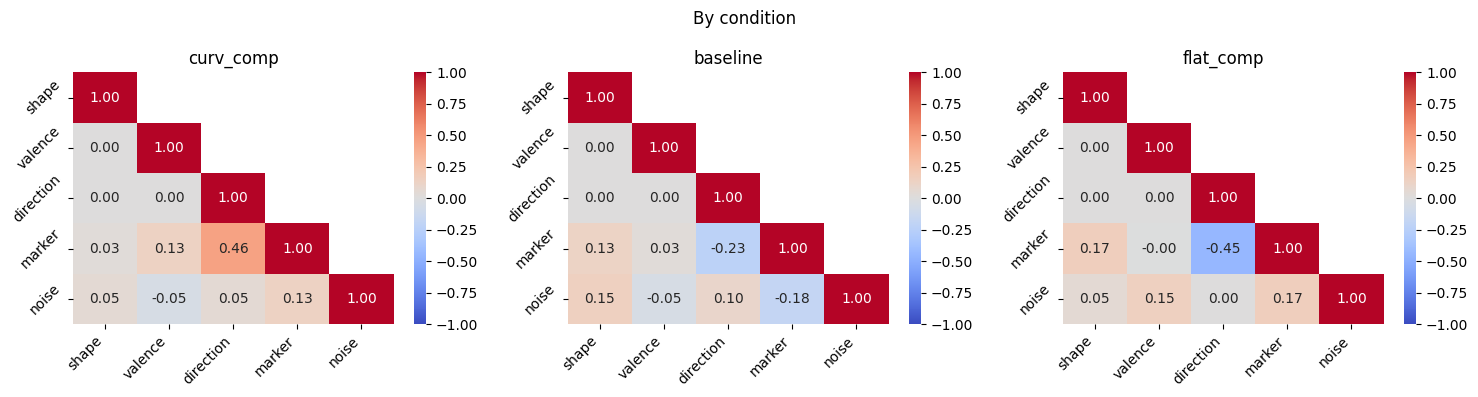

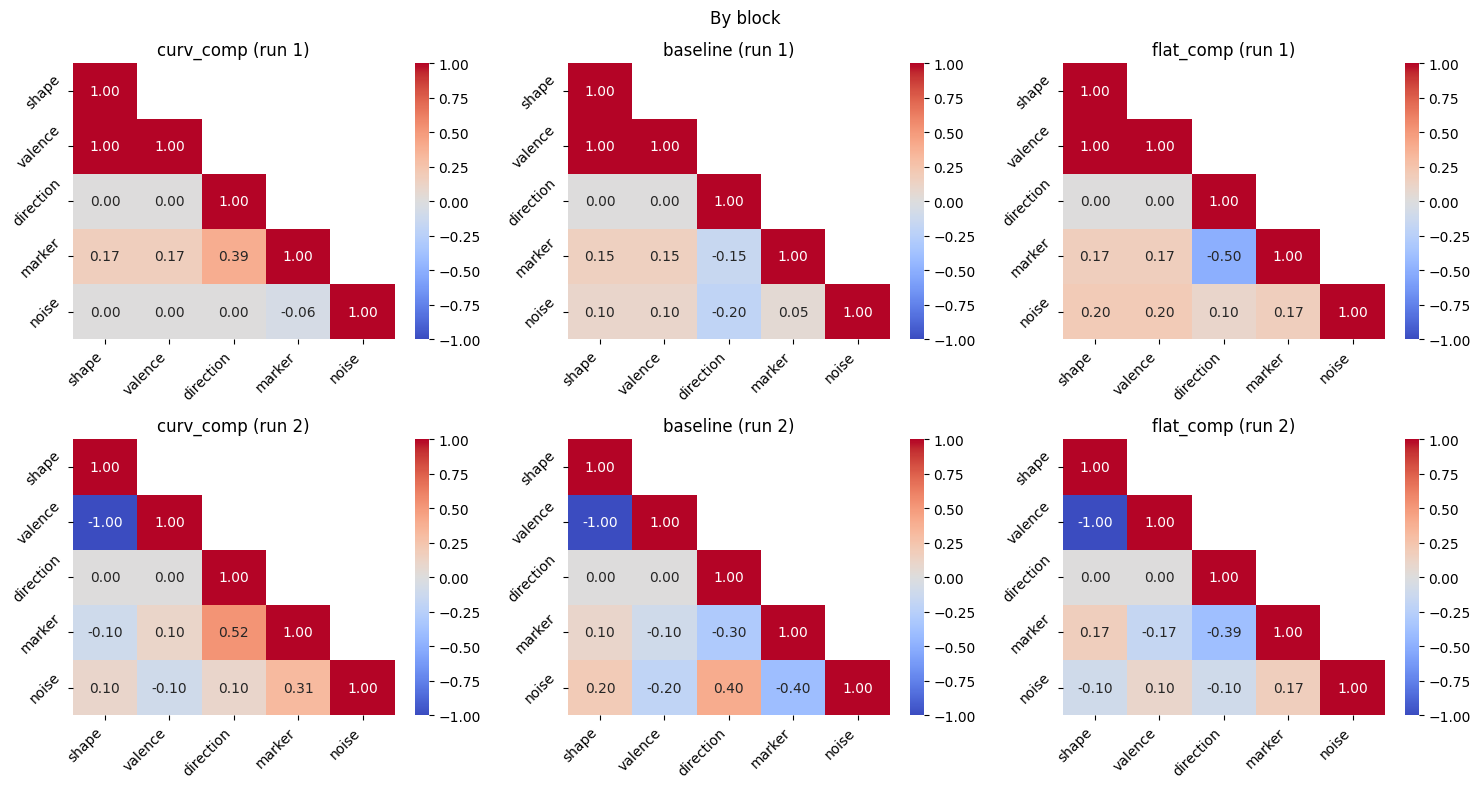

In [11]:
df['shape_category'] = df['shape'].map({'curv': -1, 'flat': 1})

var_labels = ['shape', 'valence', 'direction', 'marker', 'noise']

mask = np.triu(np.ones((5, 5), dtype=bool), k=1)

def get_vars(d):
    return [d['shape_category'], d['valence_direction'], d['direction'], d['marker_direction'], d['noise_direction']]

def plot_heatmap(ax, data, title):
    corr = np.corrcoef(get_vars(data))
    sns.heatmap(corr, annot=True, mask=mask, vmin=-1, vmax=1, cmap='coolwarm', center=0, ax=ax,
                xticklabels=var_labels, yticklabels=var_labels, fmt='.2f')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    ax.set_title(title)

# --- full session ---
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_heatmap(ax, df, 'Binarized variable correlations, full session')
plt.tight_layout()
plt.show()

# --- by condition ---
fig, axs = plt.subplots(1, n_conds, figsize=(n_conds*5, 4))
for ax, cond in zip(axs, ['curv_comp', 'baseline', 'flat_comp']):
    plot_heatmap(ax, df[df['condition'] == cond], cond)
plt.suptitle('By condition')
plt.tight_layout()
plt.show()

# --- by block ---
fig, axs = plt.subplots(n_runs, n_conds, figsize=(n_conds*5, n_runs*4))
axs = axs.flatten()
for i, blockN in enumerate([2, 1, 3, 5, 4, 6]):
    run = 1 if blockN <= 3 else 2
    df_block = df[df['blockN'] == blockN]
    cond = df_block['condition'].iloc[0]
    plot_heatmap(axs[i], df_block, f'{cond} (run {run})')
plt.suptitle('By block')
plt.tight_layout()
plt.show()


### save

In [12]:
df.to_csv(f'../../data/trials_{version}.csv', index=False)

### generate sessions

In [13]:
sess_types = ['A', 'B', 'C', 'D']
block_orders = [[0,1,2, 3,5,4], # BCF (C0F1) -> BFC' (C1F0)
                [3,4,5, 0,2,1], # BCF (C1F0) -> BFC' (C0F1)
                [0,2,1, 3,4,5], # BFC' (C0F1) -> BCF (C1F0)
                [3,5,4, 0,1,2]] # BFC' (C1F0) -> BCF (C0F1)

sess_types_df = pd.DataFrame({'block_order': block_orders}, index=sess_types)
sess_types_df.to_csv('../../data/sess_types_df.csv')
sess_types_df

,block_order
A,"[0, 1, 2, 3, 5, 4]"
B,"[3, 4, 5, 0, 2, 1]"
C,"[0, 2, 1, 3, 4, 5]"
D,"[3, 5, 4, 0, 1, 2]"


In [14]:
# find indices and flip
df['valence_flipped'] = (
    ((df['shape'] == 'curv') & (df['valence'] == 'rew')) |
    ((df['shape'] == 'flat') & (df['valence'] == 'pen'))
)
tst_df = df[df['valence_flipped']]
print(tst_df['blockN'].value_counts())
print(len(df['valence_flipped']))
print(len(df['blockN'] >= 4))
mismatch = df['valence_flipped'] != (df['blockN'] >= 4)
# print(df[mismatch][['blockN', 'valence_flipped']])
assert (df['valence_flipped'] == (df['blockN'] >= 4)).all()

blockN
4    40
5    40
6    40
Name: count, dtype: int64
240
240
